# Surrogate Workflow for 4-Factor Tip-Gap Study with `pymoo`

This notebook reproduces the surrogate modeling workflow for the 4-factor axis short-edge study and uses `pymoo` for NSGA-II.

Inputs:
- `magnet_thickness_mm`
- `magnet_length_mm`
- `v_angle_deg`
- `tip_gap_mm`

Targets:
- `loaded_torque_mean`
- `loaded_torque_ripple_pct`
- `cogging_torque_pkpk`
- `loaded_force_max`

Workflow:
1. Load FEMM summary CSV
2. Train Random Forest surrogate
3. Check 5-fold CV R²
4. Predict 1000 LHS candidates and inspect Pareto behavior
5. Compute magnet usage
6. Run `pymoo` NSGA-II on surrogate (`maximize torque`, `minimize magnet area`)


In [65]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.multioutput import MultiOutputRegressor

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

BASE_DIR = Path('/Users/dohyunkim/Documents/Window')
SUMMARY_CSV = BASE_DIR / 'axis_shortedge_ccf_4factor_50point_tipgap_summary.csv'
OUT_DIR = BASE_DIR / 'notebook_outputs_surrogate_4factor_tipgap_pymoo'
OUT_DIR.mkdir(exist_ok=True)

FEATURES = ['magnet_thickness_mm', 'magnet_length_mm', 'v_angle_deg', 'tip_gap_mm']
TARGETS = ['loaded_torque_mean', 'loaded_torque_ripple_pct', 'cogging_torque_pkpk', 'loaded_force_max']

plt.style.use('default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


In [66]:
df = pd.read_csv(SUMMARY_CSV)
df['completed_bool'] = df['completed_design'].astype(str).str.lower().isin(['true', '1'])
df = df.loc[df['completed_bool']].copy()
print('rows =', len(df))
df.head()

rows = 50


,run,coded_thickness,coded_length,coded_v_angle,coded_tip_gap,magnet_thickness_mm,magnet_length_mm,v_angle_deg,v_included_angle_deg,tip_gap_mm,center_chord_mm,magnet_center_offset_deg,completed_design,loaded_torque_mean,loaded_torque_min,loaded_torque_max,loaded_torque_pkpk,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,loaded_force_mean,completed_bool
0,301,-0.972088,-0.420757,0.385224,-0.705045,2.542,13.390,57.315,114.630,1.090,12.359723,17.545114,1,24.813967,20.935183,29.108816,8.173633,32.939644,0.018369,1291.327706,910.643386,True
1,302,0.405813,0.759986,-0.404249,0.800040,4.609,16.224,47.447,94.894,4.100,16.051443,23.047780,1,34.229469,27.979787,40.126930,12.147142,35.487382,0.131715,999.666026,612.734415,True
2,303,-0.914576,0.820477,0.352920,0.942620,2.628,16.369,56.912,113.824,4.385,18.099490,26.196495,1,30.653800,26.845840,33.680400,6.834560,22.295964,0.097857,1071.928223,678.317679,True
3,304,-0.753312,-0.074688,0.166191,0.778365,2.870,14.221,54.577,109.154,4.057,15.645625,22.432863,1,24.382166,20.431111,29.282371,8.851260,36.302190,0.018025,1124.305726,795.326962,True
4,305,-0.637541,-0.011554,0.936845,-0.342906,3.044,14.372,64.211,128.422,1.814,14.754582,21.092081,1,33.116859,28.303813,38.007581,9.703768,29.301594,0.032455,1133.518375,783.436226,True


## Basic data check

In [67]:
df[FEATURES + TARGETS].describe().T

,count,mean,std,min,25%,50%,75%,max
magnet_thickness_mm,50.0,3.999320,0.875643,2.542000,3.245750,3.987000,4.730500,5.449000
magnet_length_mm,50.0,14.402880,1.403021,12.030000,13.192500,14.402000,15.562250,16.776000
v_angle_deg,50.0,52.482260,7.291891,40.378000,46.471750,52.379500,58.719750,64.650000
tip_gap_mm,50.0,2.497880,1.161409,0.539000,1.530250,2.492000,3.460500,4.449000
loaded_torque_mean,50.0,29.544743,7.923064,13.194608,24.811672,29.222937,33.345943,53.543635
loaded_torque_ripple_pct,50.0,32.051514,6.237320,17.762779,29.824732,32.954059,35.943042,42.966755
cogging_torque_pkpk,50.0,0.068011,0.071343,0.001077,0.018111,0.043254,0.093711,0.283319
loaded_force_max,50.0,1066.589963,113.048128,699.919389,1029.273683,1070.800778,1131.571678,1291.327706


## Train surrogate and check 5-fold CV

In [68]:
x = df[FEATURES]
y = df[TARGETS]

model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=20260728,
    )
)

cv = KFold(n_splits=5, shuffle=True, random_state=20260728)
y_cv = cross_val_predict(model, x, y, cv=cv)

cv_r2 = pd.DataFrame({
    'target': TARGETS,
    'cv_r2': [r2_score(y.iloc[:, i], y_cv[:, i]) for i in range(len(TARGETS))],
})
cv_r2

,target,cv_r2
0,loaded_torque_mean,0.629979
1,loaded_torque_ripple_pct,0.754303
2,cogging_torque_pkpk,0.488503
3,loaded_force_max,0.630800


In [69]:
model.fit(x, y)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...tate=20260728)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[RandomForestR...tate=20260728), RandomForestR...tate=20260728), RandomForestR...tate=20260728), RandomForestR...tate=20260728)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['magnet_thickness_mm','magnet_length_mm','v_angle_deg','tip_gap_mm']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,4
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",20260728
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


## Helper functions

In [70]:
def latin_hypercube(bounds, n_samples, seed=20260728):
    rng = np.random.default_rng(seed)
    data = {}
    for name, (lo, hi) in bounds.items():
        bins = (np.arange(n_samples) + rng.random(n_samples)) / n_samples
        rng.shuffle(bins)
        data[name] = lo + bins * (hi - lo)
    return pd.DataFrame(data)


def pareto_mask_max_torque_min_ripple(torque, ripple):
    n = len(torque)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        dominated = (
            (torque >= torque[i])
            & (ripple <= ripple[i])
            & ((torque > torque[i]) | (ripple < ripple[i]))
        )
        dominated[i] = False
        if dominated.any():
            keep[i] = False
    return keep


def magnet_usage_area(length_mm, thickness_mm, v_angle_deg):
    piece = length_mm * thickness_mm * np.sin(np.deg2rad(v_angle_deg))
    return 8.0 * piece


## Predict 1000 LHS candidates

In [71]:
bounds = {name: (float(df[name].min()), float(df[name].max())) for name in FEATURES}
candidates = latin_hypercube(bounds, n_samples=1000, seed=20260728)
y_pred = model.predict(candidates)

pred_df = candidates.copy()
for idx, target in enumerate(TARGETS):
    pred_df[target] = y_pred[:, idx]

pred_df['pareto_torque_ripple'] = pareto_mask_max_torque_min_ripple(
    pred_df['loaded_torque_mean'].to_numpy(),
    pred_df['loaded_torque_ripple_pct'].to_numpy(),
)
pred_df['total_magnet_area_mm2'] = magnet_usage_area(
    pred_df['magnet_length_mm'].to_numpy(),
    pred_df['magnet_thickness_mm'].to_numpy(),
    pred_df['v_angle_deg'].to_numpy(),
)

pareto_1000 = pred_df.loc[pred_df['pareto_torque_ripple']].sort_values(
    ['loaded_torque_mean', 'loaded_torque_ripple_pct'],
    ascending=[False, True],
)
print('Pareto count =', len(pareto_1000))
pareto_1000.head(12)

Pareto count = 3


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,tip_gap_mm,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,pareto_torque_ripple,total_magnet_area_mm2
684,5.412257,16.764453,64.031571,0.551069,46.013859,19.668932,0.099902,799.808591,True,652.581224
890,5.290785,16.711492,63.035819,4.016943,43.184704,19.551400,0.104952,850.801335,True,630.440935
738,4.585936,16.579432,62.875510,3.913369,42.431344,19.530649,0.099385,876.797523,True,541.360354


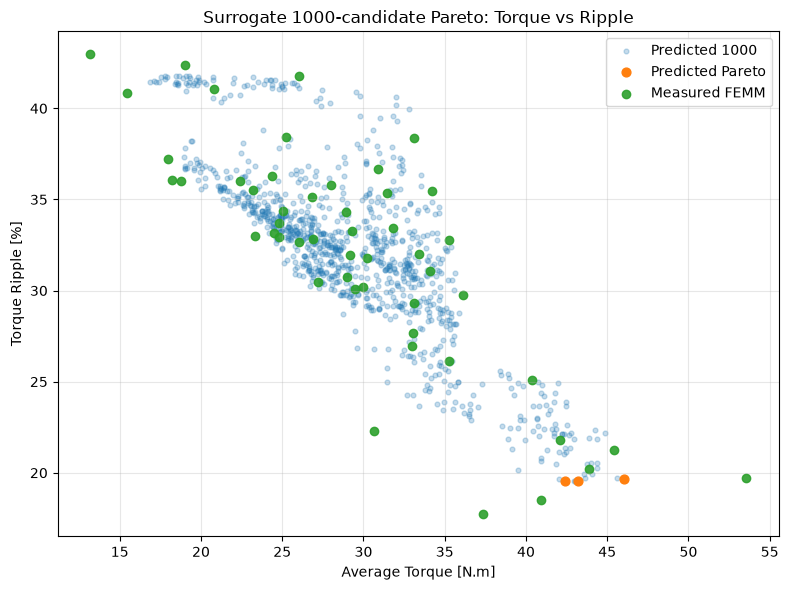

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pred_df['loaded_torque_mean'], pred_df['loaded_torque_ripple_pct'], s=12, alpha=0.25, label='Predicted 1000')
ax.scatter(pareto_1000['loaded_torque_mean'], pareto_1000['loaded_torque_ripple_pct'], s=40, label='Predicted Pareto')
ax.scatter(df['loaded_torque_mean'], df['loaded_torque_ripple_pct'], s=36, alpha=0.9, label='Measured FEMM')
ax.set_xlabel('Average Torque [N.m]')
ax.set_ylabel('Torque Ripple [%]')
ax.set_title('Surrogate 1000-candidate Pareto: Torque vs Ripple')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Sensitivity table (Spearman)

In [73]:
sens = df[
    FEATURES + ['loaded_torque_mean', 'loaded_torque_ripple_pct', 'cogging_torque_pkpk', 'loaded_force_max']
].corr(method='spearman')

sens.loc[
    FEATURES,
    ['loaded_torque_mean', 'loaded_torque_ripple_pct', 'cogging_torque_pkpk', 'loaded_force_max'],
].round(3)

,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max
magnet_thickness_mm,0.337,-0.054,0.468,-0.646
magnet_length_mm,0.710,-0.352,0.694,-0.621
v_angle_deg,0.447,-0.738,-0.168,-0.097
tip_gap_mm,-0.066,0.216,0.019,-0.175


## `pymoo` NSGA-II on surrogate: maximize torque, minimize magnet area

In [74]:
class TorqueMagnetAreaProblem(Problem):
    def __init__(self, model, xl, xu):
        super().__init__(n_var=4, n_obj=2, n_constr=0, xl=xl, xu=xu)
        self.model = model

    def _evaluate(self, X, out, *args, **kwargs):
        X_df = pd.DataFrame(X, columns=FEATURES)
        pred = self.model.predict(X_df)
        torque = pred[:, 0]
        area = magnet_usage_area(X[:, 1], X[:, 0], X[:, 2])
        # pymoo minimizes by default
        out['F'] = np.column_stack([-torque, area])
        out['pred'] = pred

xl = df[FEATURES].min().to_numpy(dtype=float)
xu = df[FEATURES].max().to_numpy(dtype=float)
problem = TorqueMagnetAreaProblem(model, xl=xl, xu=xu)


In [75]:
algorithm = NSGA2(pop_size=300)
result = minimize(
    problem,
    algorithm,
    ('n_gen', 60),
    seed=20260728,
    verbose=False,
)

X = result.X
F = result.F
X_df = pd.DataFrame(X, columns=FEATURES)
pred = model.predict(X_df)

nsga_df = pd.DataFrame(X, columns=FEATURES)
for i, target in enumerate(TARGETS):
    nsga_df[target] = pred[:, i]
nsga_df['total_magnet_area_mm2'] = magnet_usage_area(
    nsga_df['magnet_length_mm'].to_numpy(),
    nsga_df['magnet_thickness_mm'].to_numpy(),
    nsga_df['v_angle_deg'].to_numpy(),
)
nsga_df = nsga_df.sort_values(['loaded_torque_mean', 'total_magnet_area_mm2'], ascending=[False, True]).reset_index(drop=True)

print('NSGA result rows =', len(nsga_df))
nsga_df.head(15)

NSGA result rows = 300


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,tip_gap_mm,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,total_magnet_area_mm2
0,5.328376,16.540730,61.571732,0.714225,46.441101,20.164184,0.105150,796.920261,620.058705
1,5.322188,16.472435,61.555572,0.809868,46.411758,20.169443,0.105483,795.951358,616.687268
2,5.322188,16.472460,61.496165,0.865944,46.373665,20.454143,0.104932,801.176764,616.341494
3,5.322188,16.472460,61.075525,0.865944,46.329455,21.072063,0.104337,818.815686,613.867691
4,5.322188,16.472460,61.075525,1.381019,46.329455,21.072063,0.104234,818.843310,613.867691
5,5.327953,16.539766,59.263771,1.335394,46.235864,21.884821,0.103289,828.056522,605.955041
6,5.327953,16.472636,59.263771,1.335394,46.206520,21.890080,0.103622,827.087619,603.495678
7,5.327953,16.472636,59.263771,1.155847,46.206520,21.890080,0.104107,827.059996,603.495678
8,5.065615,16.535011,61.692571,1.076724,46.130045,20.202538,0.104370,848.752949,589.949118
9,5.044890,16.475853,61.917306,1.043859,46.100702,20.041938,0.104559,847.501642,586.665663


Measured torque-area Pareto count = 11


,run,magnet_thickness_mm,magnet_length_mm,v_angle_deg,tip_gap_mm,loaded_torque_mean,total_magnet_area_mm2
0,311,5.449,16.514,62.054,0.927,53.543635,635.933041
1,333,3.966,16.701,58.835,1.519,45.439407,453.415989
2,316,4.060,16.270,58.374,2.586,42.099656,449.969058
3,308,3.864,15.506,61.022,2.057,40.340056,419.313202
4,306,2.924,16.776,63.798,3.575,37.378213,352.099843
5,305,3.044,14.372,64.211,1.814,33.116859,315.129054
6,303,2.628,16.369,56.912,4.385,30.653800,288.333429
7,341,2.849,14.665,53.526,0.882,29.506219,268.775071
8,325,2.713,15.243,50.278,1.899,27.179699,254.462426
9,327,2.576,13.946,60.915,3.012,26.022576,251.157994


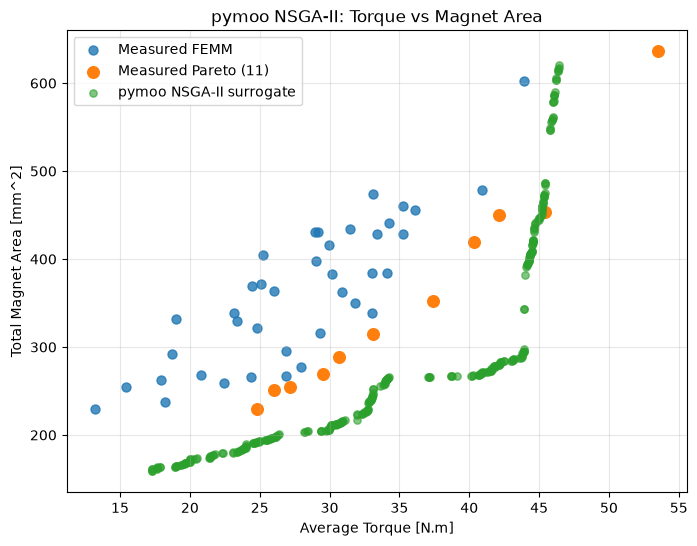

In [76]:
measured = df.copy()
measured['total_magnet_area_mm2'] = magnet_usage_area(
    measured['magnet_length_mm'].to_numpy(),
    measured['magnet_thickness_mm'].to_numpy(),
    measured['v_angle_deg'].to_numpy(),
)

torque = measured['loaded_torque_mean'].to_numpy()
area = measured['total_magnet_area_mm2'].to_numpy()
measured_keep = np.ones(len(measured), dtype=bool)
for i in range(len(measured)):
    dominated = (
        (torque >= torque[i])
        & (area <= area[i])
        & ((torque > torque[i]) | (area < area[i]))
    )
    dominated[i] = False
    if dominated.any():
        measured_keep[i] = False

measured_pareto = measured.loc[measured_keep].sort_values(
    ['loaded_torque_mean', 'total_magnet_area_mm2'],
    ascending=[False, True],
).reset_index(drop=True)

print('Measured torque-area Pareto count =', len(measured_pareto))
display(measured_pareto[['run', 'magnet_thickness_mm', 'magnet_length_mm', 'v_angle_deg', 'tip_gap_mm', 'loaded_torque_mean', 'total_magnet_area_mm2']])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(measured['loaded_torque_mean'], measured['total_magnet_area_mm2'], s=42, alpha=0.8, label='Measured FEMM')
ax.scatter(measured_pareto['loaded_torque_mean'], measured_pareto['total_magnet_area_mm2'], s=70, label='Measured Pareto (11)')
ax.scatter(nsga_df['loaded_torque_mean'], nsga_df['total_magnet_area_mm2'], s=28, alpha=0.6, label='pymoo NSGA-II surrogate')
ax.set_xlabel('Average Torque [N.m]')
ax.set_ylabel('Total Magnet Area [mm^2]')
ax.set_title('pymoo NSGA-II: Torque vs Magnet Area')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [77]:
nsga_df[['magnet_thickness_mm', 'magnet_length_mm', 'v_angle_deg', 'tip_gap_mm', 'loaded_torque_mean', 'loaded_torque_ripple_pct', 'cogging_torque_pkpk', 'total_magnet_area_mm2']].head(20)

,magnet_thickness_mm,magnet_length_mm,v_angle_deg,tip_gap_mm,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,total_magnet_area_mm2
0,5.328376,16.540730,61.571732,0.714225,46.441101,20.164184,0.105150,620.058705
1,5.322188,16.472435,61.555572,0.809868,46.411758,20.169443,0.105483,616.687268
2,5.322188,16.472460,61.496165,0.865944,46.373665,20.454143,0.104932,616.341494
3,5.322188,16.472460,61.075525,0.865944,46.329455,21.072063,0.104337,613.867691
4,5.322188,16.472460,61.075525,1.381019,46.329455,21.072063,0.104234,613.867691
5,5.327953,16.539766,59.263771,1.335394,46.235864,21.884821,0.103289,605.955041
6,5.327953,16.472636,59.263771,1.335394,46.206520,21.890080,0.103622,603.495678
7,5.327953,16.472636,59.263771,1.155847,46.206520,21.890080,0.104107,603.495678
8,5.065615,16.535011,61.692571,1.076724,46.130045,20.202538,0.104370,589.949118
9,5.044890,16.475853,61.917306,1.043859,46.100702,20.041938,0.104559,586.665663


In [78]:
import plotly.express as px

surrogate_plot_df = pred_df.copy().reset_index(drop=True)
surrogate_plot_df['candidate_id'] = np.arange(1, len(surrogate_plot_df) + 1)
top_torque_surrogate_df = surrogate_plot_df.nlargest(12, 'loaded_torque_mean').copy()

print('Surrogate candidate rows =', len(surrogate_plot_df))
display(
    top_torque_surrogate_df[
        ['candidate_id', 'magnet_length_mm', 'v_angle_deg', 'magnet_thickness_mm', 'loaded_torque_mean', 'loaded_torque_ripple_pct', 'total_magnet_area_mm2']
    ]
)


Surrogate candidate rows = 1000


,candidate_id,magnet_length_mm,v_angle_deg,magnet_thickness_mm,loaded_torque_mean,loaded_torque_ripple_pct,total_magnet_area_mm2
684,685,16.764453,64.031571,5.412257,46.013859,19.668932,652.581224
660,661,16.749869,64.149775,4.840524,45.572047,19.707765,583.721729
215,216,16.359185,59.729370,5.033558,44.833774,22.158090,568.940105
23,24,16.291721,61.601417,4.592558,44.370229,20.527147,526.534177
441,442,16.397804,62.156637,3.947215,44.360501,20.288332,457.857781
947,948,15.852135,62.089432,4.927554,44.358206,21.852555,552.209394
520,521,16.285037,59.893855,4.499200,44.245350,22.340341,507.083166
923,924,16.703022,61.834549,5.427716,44.067168,19.908442,639.393146
942,943,16.330781,61.693126,3.991416,43.984571,20.518143,459.107141
549,550,16.549761,59.535900,5.364764,43.854782,21.899912,612.227574


In [79]:
fig = px.scatter_3d(
    surrogate_plot_df,
    x='magnet_length_mm',
    y='magnet_thickness_mm',
    z='v_angle_deg',
    color='loaded_torque_mean',
    color_continuous_scale='Viridis',
    hover_data={
        'candidate_id': True,
        'magnet_length_mm': ':.3f',
        'v_angle_deg': ':.3f',
        'magnet_thickness_mm': ':.3f',
        'loaded_torque_mean': ':.3f',
        'loaded_torque_ripple_pct': ':.3f',
        'total_magnet_area_mm2': ':.3f',
    },
    title='Surrogate 1000-candidate 3D view: z = V angle, color = torque',
)
fig.update_traces(marker=dict(size=4.5, opacity=0.8))
fig.update_layout(
    scene=dict(
        xaxis_title='Length [mm]',
        yaxis_title='Thickness [mm]',
        zaxis_title='V angle [deg]',
    ),
    height=720,
)
fig.show()


In [80]:
fig = px.scatter_3d(
    surrogate_plot_df,
    x='magnet_length_mm',
    y='magnet_thickness_mm',
    z='v_angle_deg',
    color='loaded_torque_ripple_pct',
    color_continuous_scale='Plasma_r',
    hover_data={
        'candidate_id': True,
        'magnet_length_mm': ':.3f',
        'v_angle_deg': ':.3f',
        'magnet_thickness_mm': ':.3f',
        'loaded_torque_mean': ':.3f',
        'loaded_torque_ripple_pct': ':.3f',
        'total_magnet_area_mm2': ':.3f',
    },
    title='Surrogate 1000-candidate 3D view: z = V angle, color = torque ripple',
)
fig.update_traces(marker=dict(size=4.5, opacity=0.8))
fig.update_layout(
    scene=dict(
        xaxis_title='Length [mm]',
        yaxis_title='Thickness [mm]',
        zaxis_title='V angle [deg]',
    ),
    height=720,
)
fig.show()


## Notes

Interpretation cautions:
- This notebook uses a surrogate trained on only 50 FEMM samples.
- Any 1000-candidate Pareto or `pymoo` NSGA Pareto here is **surrogate-based**, not direct FEMM truth.
- Use this notebook to pick promising regions, then validate those points with new FEMM runs.
